https://huggingface.co/datasets/Hello-SimpleAI/HC3

In [70]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json

pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')

In [71]:
# 2. Load HC3 directly from HuggingFace
urls = {
    'reddit_eli5': 'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/reddit_eli5.jsonl',
    'open_qa':     'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/open_qa.jsonl',
    'medicine':    'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/medicine.jsonl',
    'finance':     'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/finance.jsonl',
    'wiki_csai':   'https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/wiki_csai.jsonl',
}

records = []
for source, url in urls.items():
    response = requests.get(url)
    for line in response.text.strip().split('\n'):
        row = json.loads(line)
        row['source'] = source
        records.append(row)

df_raw = pd.DataFrame(records)
print(f'Raw rows: {len(df_raw):,}')
df_raw.head(3)

Raw rows: 24,322


,question,human_answers,chatgpt_answers,index,source
0,"Why is every book I hear about a "" NY Times # 1 Best Seller "" ? ELI5 : Why is every book I hear ...","[Basically there are many categories of "" Best Seller "" . Replace "" Best Seller "" by something l...","[There are many different best seller lists that are published by various organizations, and the...",NaN,reddit_eli5
1,"If salt is so bad for cars , why do we use it on the roads ? As the title states , why do we use...",[salt is good for not dying in car crashes and car crashes are worse for cars then salt . Some p...,[Salt is used on roads to help melt ice and snow and improve traction during the winter months. ...,NaN,reddit_eli5
2,Why do we still have SD TV channels when HD looks like SD on an old TV ? Could n't we just have ...,[The way it works is that old TV stations got a certain amount of bandwidth to replace their old...,[There are a few reasons why we still have SD (standard definition) TV channels: \n1. Some peopl...,NaN,reddit_eli5


In [72]:
print(df_raw.columns.tolist())
print(df_raw.head(2))

['question', 'human_answers', 'chatgpt_answers', 'index', 'source']
                                                                                              question  \
0  Why is every book I hear about a " NY Times # 1 Best Seller " ? ELI5 : Why is every book I hear ...   
1  If salt is so bad for cars , why do we use it on the roads ? As the title states , why do we use...   

                                                                                         human_answers  \
0  [Basically there are many categories of " Best Seller " . Replace " Best Seller " by something l...   
1  [salt is good for not dying in car crashes and car crashes are worse for cars then salt . Some p...   

                                                                                       chatgpt_answers  \
0  [There are many different best seller lists that are published by various organizations, and the...   
1  [Salt is used on roads to help melt ice and snow and improve traction during th

In [73]:
# 3. Flatten into one document per response
records = []
for idx, row in df_raw.iterrows():
    for i, ans in enumerate(row['human_answers']):
        records.append({
            'doc_id':      f"{idx}_H{i}",
            'question_id': idx,
            'question':    row['question'],
            'text':        ans,
            'author_type': 'human',
            'source':      row['source']
        })
    for i, ans in enumerate(row['chatgpt_answers']):
        records.append({
            'doc_id':      f"{idx}_AI{i}",
            'question_id': idx,
            'question':    row['question'],
            'text':        ans,
            'author_type': 'chatgpt',
            'source':      row['source']
        })

docs = pd.DataFrame(records)
docs['char_length'] = docs['text'].str.len()
docs['word_count']  = docs['text'].str.split().str.len()

In [74]:
# 4. How many documents?
print(f'Total documents: {len(docs):,}\n')
print('By author type:')
print(docs['author_type'].value_counts().to_string())
print('\nBy source domain:')
print(docs['source'].value_counts().to_string())

Total documents: 85,449

By author type:
author_type
human      58546
chatgpt    26903

By source domain:
source
reddit_eli5    67996
finance         8436
open_qa         4748
medicine        2585
wiki_csai       1684


In [75]:
# 5. Average length
print('Character length')
print(docs['char_length'].describe().round(1).to_string())
print('\nWord count')
print(docs['word_count'].describe().round(1).to_string())
print('\nAvg chars by author type')
print(docs.groupby('author_type')['char_length'].mean().round(1).to_string())

Character length
count    85449.0
mean       784.5
std        732.6
min          0.0
25%        289.0
50%        631.0
75%       1085.0
max      36793.0

Word count
count    85449.0
mean       146.2
std        141.1
min          0.0
25%         57.0
50%        118.0
75%        193.0
max       7904.0

Avg chars by author type
author_type
chatgpt    1010.5
human       680.7


In [76]:
# 6. Max and min lengths
shortest = docs.loc[docs['char_length'].idxmin()]
longest  = docs.loc[docs['char_length'].idxmax()]

print('Shortest document')
print(f"doc_id: {shortest['doc_id']}")
print(f"author_type: {shortest['author_type']}")
print(f"char_length: {shortest['char_length']}")
print(f"text: {shortest['text']}")

print('\nLongest document')
print(f"doc_id: {longest['doc_id']}")
print(f"author_type: {longest['author_type']}")
print(f"char_length: {longest['char_length']}")
print(f"text (first 300 chars): {longest['text'][:300]}")

Shortest document
doc_id: 17497_AI1
author_type: chatgpt
char_length: 0
text: 

Longest document
doc_id: 15050_H0
author_type: human
char_length: 36793
text (first 300 chars): Okay , explained like you 're a five year - old ( well , okay , maybe a bit older ) , without too much oversimplification , and ( hopefully ) without sounding too biased : What people call " Obamacare " is actually the Patient Protection and Affordable Care Act ( abbreviated to PPACA or ACA ) . Howe


In [77]:
# 7. OHCO structure
ohco = docs.copy()
ohco['para_num'] = ohco['text'].apply(lambda x: len([p for p in x.split('\n') if p.strip()]))

print('OHCO levels:')
print(f"source: {ohco['source'].nunique()} unique values: {ohco['source'].unique().tolist()}")
print(f"question_id: {ohco['question_id'].nunique():,} unique questions")
print(f"doc_id: {ohco['doc_id'].nunique():,} unique documents")
print(f"para_num: avg {ohco['para_num'].mean():.1f} paragraphs per document")
print(f"sent_num: computed via sentence tokenizer")
print(f"token_num: avg {ohco['word_count'].mean():.1f} tokens per document")

print('\nOHCO index:')
ohco[['source', 'question_id', 'doc_id', 'para_num', 'word_count']].head(8)

OHCO levels:
source: 5 unique values: ['reddit_eli5', 'open_qa', 'medicine', 'finance', 'wiki_csai']
question_id: 24,322 unique questions
doc_id: 85,449 unique documents
para_num: avg 1.3 paragraphs per document
sent_num: computed via sentence tokenizer
token_num: avg 146.2 tokens per document

OHCO index:


,source,question_id,doc_id,para_num,word_count
0,reddit_eli5,0,0_H0,1,134
1,reddit_eli5,0,0_H1,1,73
2,reddit_eli5,0,0_H2,1,62
3,reddit_eli5,0,0_AI0,3,207
4,reddit_eli5,1,1_H0,1,41
5,reddit_eli5,1,1_H1,1,116
6,reddit_eli5,1,1_H2,1,260
7,reddit_eli5,1,1_AI0,3,199


In [78]:
total_tokens = docs['word_count'].sum()
print(f'Estimated CORPUS rows: {total_tokens:,}')

Estimated CORPUS rows: 12,492,921


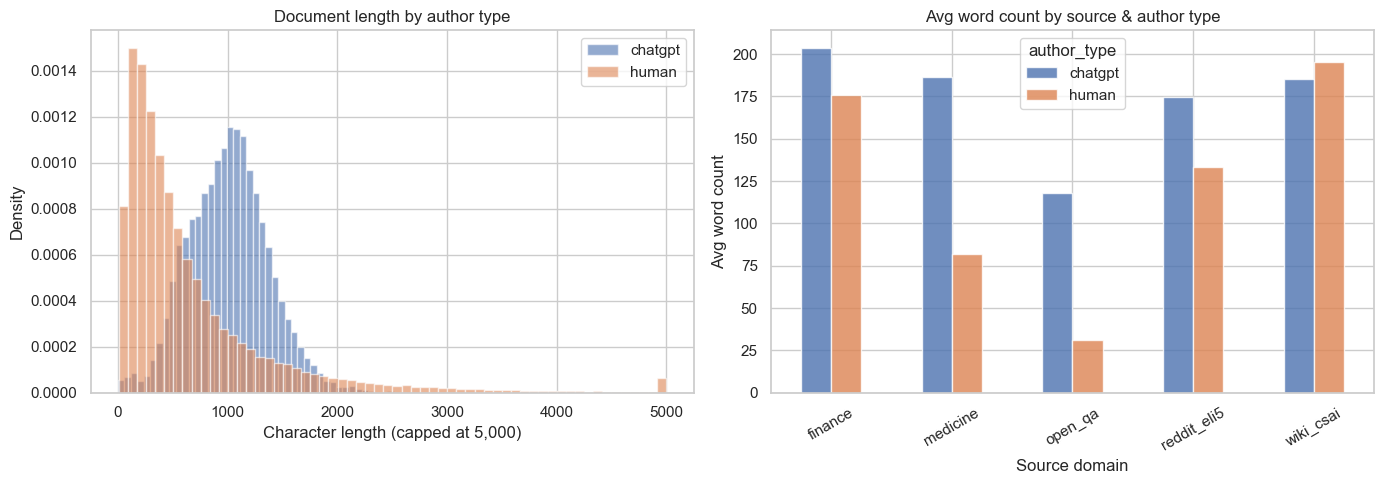

In [79]:
# 8. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for author, grp in docs.groupby('author_type'):
    axes[0].hist(grp['char_length'].clip(upper=5000), bins=60,
                 alpha=0.6, label=author, density=True)
axes[0].set_title('Document length by author type')
axes[0].set_xlabel('Character length (capped at 5,000)')
axes[0].set_ylabel('Density')
axes[0].legend()

avg = docs.groupby(['source', 'author_type'])['word_count'].mean().unstack()
avg.plot(kind='bar', ax=axes[1], alpha=0.8)
axes[1].set_title('Avg word count by source & author type')
axes[1].set_xlabel('Source domain')
axes[1].set_ylabel('Avg word count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()